# Modular Noise Package Tutorial

This notebook is a hands-on tutorial for the refactored `NoiseGenerator` and the three companion modules:

- `TemporalNoiseWrapper`
- `ArtifactInjector`
- `MultiChannelNoiseGenerator`

It also shows how to build and use a custom PSD file.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'wk7').exists():
    ROOT = ROOT.parent
if not (ROOT / 'wk7').exists():
    raise RuntimeError('Could not locate repository root containing wk7/')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from wk7.noise_module import (
    ArtifactInjector,
    MultiChannelNoiseGenerator,
    NoiseGenerator,
    TemporalNoiseWrapper,
)

MODULE_DIR = ROOT / 'wk7' / 'noise_module'
FS = 2000.0
N = 4096
plt.style.use('default')


## 1. Base `NoiseGenerator`

Use the base class when you want a stationary single-channel Gaussian process. The main entry points are:

- `build_psd(N)` to inspect the target PSD
- `generate_noise(N)` to sample a trace
- `return_metadata=True` when you want logging/debug info

({'noise_type': 'white',
  'noise_power': 1.0,
  'sampling_frequency': 2000.0,
  'seed': 1,
  'n_samples': 4096,
  'psd_total': 8392704.0,
  'config': {'noise_type': 'white',
   'noise_power': 1.0,
   'sampling_frequency': 2000.0},
  'variance': 0.999755859375,
  'mean': 0.015624999999999993,
  'frequencies': array([0.00000000e+00, 4.88281250e-01, 9.76562500e-01, ...,
         9.99023438e+02, 9.99511719e+02, 1.00000000e+03])},
 {'noise_type': 'pink',
  'noise_power': 1.0,
  'sampling_frequency': 2000.0,
  'seed': 2,
  'n_samples': 4096,
  'psd_total': 9023929.422151702,
  'config': {'noise_type': 'pink',
   'noise_power': 1.0,
   'sampling_frequency': 2000.0},
  'variance': 1.075704195328463,
  'mean': 5.551115123125783e-17,
  'frequencies': array([0.00000000e+00, 4.88281250e-01, 9.76562500e-01, ...,
         9.99023438e+02, 9.99511719e+02, 1.00000000e+03])})

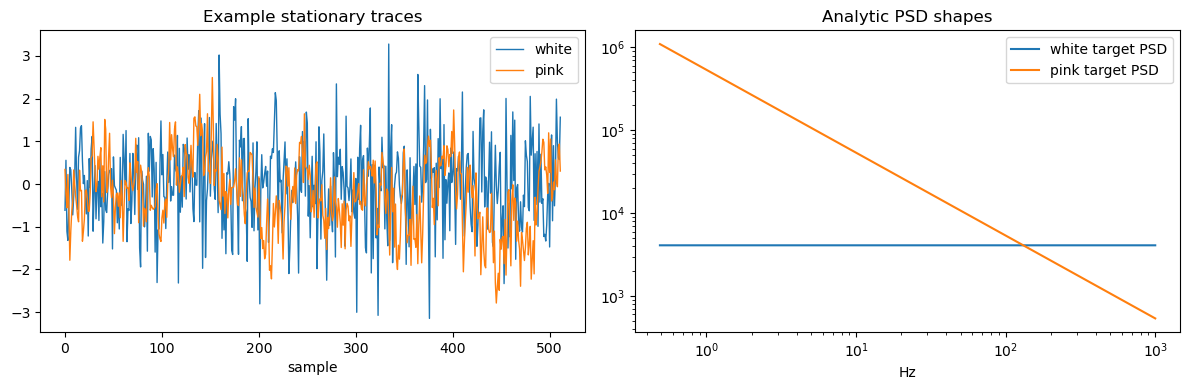

In [2]:
white_config = {
    'noise_type': 'white',
    'noise_power': 1.0,
    'sampling_frequency': FS,
}
pink_config = {
    'noise_type': 'pink',
    'noise_power': 1.0,
    'sampling_frequency': FS,
}

white_gen = NoiseGenerator(white_config, seed=1)
pink_gen = NoiseGenerator(pink_config, seed=2)
white_trace, white_meta = white_gen.generate_noise(N, return_metadata=True)
pink_trace, pink_meta = pink_gen.generate_noise(N, return_metadata=True)
freqs, white_psd = white_gen.build_psd(N)
_, pink_psd = pink_gen.build_psd(N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(white_trace[:512], label='white', lw=1)
axes[0].plot(pink_trace[:512], label='pink', lw=1)
axes[0].set_title('Example stationary traces')
axes[0].set_xlabel('sample')
axes[0].legend()

axes[1].loglog(freqs[1:], white_psd[1:], label='white target PSD')
axes[1].loglog(freqs[1:], pink_psd[1:], label='pink target PSD')
axes[1].set_title('Analytic PSD shapes')
axes[1].set_xlabel('Hz')
axes[1].legend()
plt.tight_layout()

white_meta, pink_meta


## 2. Custom PSD

`NoiseGenerator` can also load a PSD from disk. The file format is the same one the module expects internally: a NumPy array saved with shape `(2, M)`, where row 0 is frequency and row 1 is PSD value.

The cell below builds a synthetic custom PSD with a broadband slope plus a resonant bump, saves it to disk, and then uses it as `noise_type`.

/home/dwong/DELight_mtr/PCA_dev/wk7/noise_module/tutorial_custom_psd.npy


{'noise_type': 'custom',
 'noise_power': 1.0,
 'sampling_frequency': 2000.0,
 'seed': 3,
 'n_samples': 4096,
 'psd_total': 143480382.9785059,
 'config': {'noise_type': '/home/dwong/DELight_mtr/PCA_dev/wk7/noise_module/tutorial_custom_psd.npy',
  'noise_power': 1.0,
  'sampling_frequency': 2000.0},
 'variance': 16.71047402482517,
 'mean': 0.4419417382415935,
 'frequencies': array([0.00000000e+00, 4.88281250e-01, 9.76562500e-01, ...,
        9.99023438e+02, 9.99511719e+02, 1.00000000e+03])}

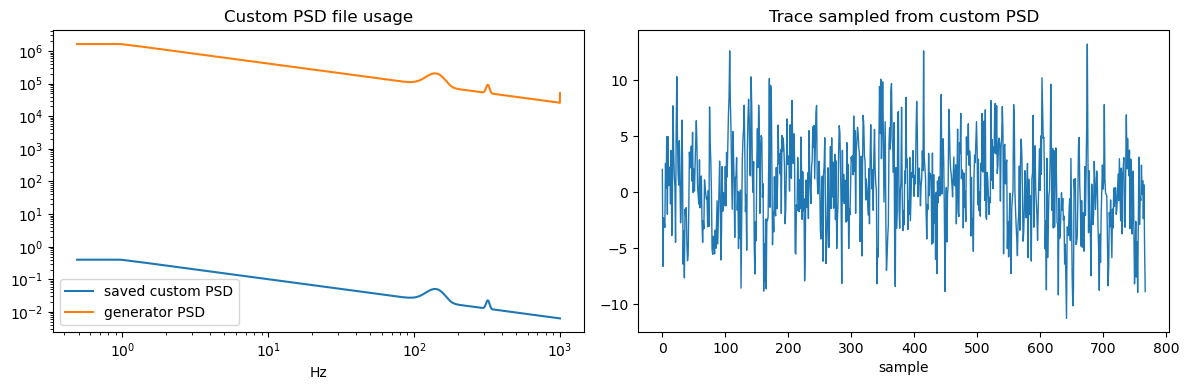

In [3]:
custom_psd_path = MODULE_DIR / 'tutorial_custom_psd.npy'
custom_freqs = np.linspace(0.0, FS / 2.0, N // 2 + 1)
safe_freqs = np.maximum(custom_freqs, 1.0)
background = 0.4 / safe_freqs**0.6
resonance = 0.03 * np.exp(-0.5 * ((custom_freqs - 140.0) / 18.0) ** 2)
line_cluster = 0.01 * np.exp(-0.5 * ((custom_freqs - 320.0) / 8.0) ** 2)
custom_psd_values = background + resonance + line_cluster
np.save(custom_psd_path, np.vstack([custom_freqs, custom_psd_values]))

custom_config = {
    'noise_type': str(custom_psd_path),
    'noise_power': 1.0,
    'sampling_frequency': FS,
}
custom_gen = NoiseGenerator(custom_config, seed=3)
custom_trace, custom_meta = custom_gen.generate_noise(N, return_metadata=True)
custom_eval_freqs, custom_eval_psd = custom_gen.build_psd(N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].loglog(custom_freqs[1:], custom_psd_values[1:], label='saved custom PSD')
axes[0].loglog(custom_eval_freqs[1:], custom_eval_psd[1:], label='generator PSD')
axes[0].set_title('Custom PSD file usage')
axes[0].set_xlabel('Hz')
axes[0].legend()

axes[1].plot(custom_trace[:768], lw=1)
axes[1].set_title('Trace sampled from custom PSD')
axes[1].set_xlabel('sample')
plt.tight_layout()

print(custom_psd_path)
custom_meta


## 3. `TemporalNoiseWrapper`

Use this wrapper when you want slow non-stationarity on top of a stationary baseline.

This demo shows:
- segment-wise non-stationarity in **frequency PSD**
- temporal difference between baseline and non-stationary output
- drift and local variance changes across time


{'mode': 'piecewise',
 'piecewise': {'segments': [{'start': 0,
    'end': 819,
    'noise_power': 1.5373617161296045,
    'noise_type': '/home/dwong/DELight_mtr/PCA_dev/wk7/noise_module/tutorial_custom_psd.npy'},
   {'start': 819,
    'end': 1638,
    'noise_power': 1.5738680762784747,
    'noise_type': '/home/dwong/DELight_mtr/PCA_dev/wk7/noise_module/tutorial_custom_psd.npy'},
   {'start': 1638,
    'end': 2457,
    'noise_power': 1.1680914151945325,
    'noise_type': '/home/dwong/DELight_mtr/PCA_dev/wk7/noise_module/tutorial_custom_psd.npy'},
   {'start': 2457,
    'end': 3276,
    'noise_power': 1.382091327684388,
    'noise_type': '/home/dwong/DELight_mtr/PCA_dev/wk7/noise_module/tutorial_custom_psd.npy'},
   {'start': 3276,
    'end': 4096,
    'noise_power': 1.4587988016064222,
    'noise_type': '/home/dwong/DELight_mtr/PCA_dev/wk7/noise_module/tutorial_custom_psd.npy'}],
  'crossfade_len': 128},
 'variance_envelope_range': [0.9184592216951293, 1.3183549416089146],
 'drift_std':

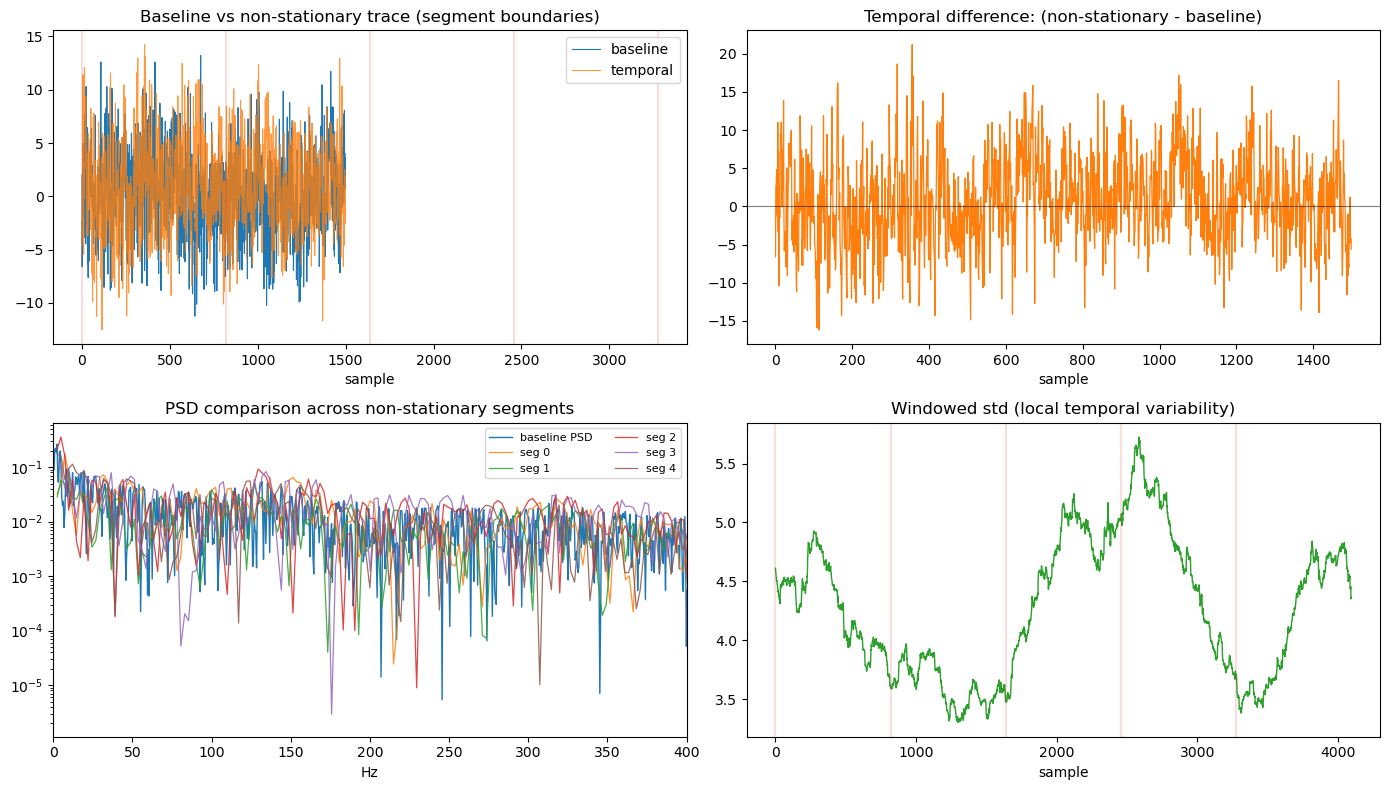

In [4]:
temporal_config = {
    'mode': 'piecewise',
    'n_segments': 5,
    'crossfade_len': 128,
    'vary_noise_power': True,
    'noise_power_scale_range': [0.5, 1.6],
    'add_drift': True,
    'drift_type': 'spline',
    'drift_sigma': 0.08,
    'drift_n_knots': 7,
    'variance_modulation': True,
    'variance_scale_range': [0.7, 1.3],
    'variance_n_knots': 7,
}
temporal = TemporalNoiseWrapper(temporal_config, seed=4)
temporal_trace, temporal_meta = temporal.apply(
    custom_trace,
    base_generator=custom_gen,
    return_metadata=True,
)

def quick_psd(x, fs):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    window = np.hanning(len(x))
    X = np.fft.rfft(x * window)
    psd = (np.abs(X) ** 2) / (fs * np.sum(window ** 2))
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    return freqs, psd

base_freq, base_psd = quick_psd(custom_trace, FS)
segments = temporal_meta['piecewise']['segments']
delta_trace = temporal_trace - custom_trace

# Windowed std to show local temporal variation.
win = 256
windowed_std = np.array([
    np.std(temporal_trace[max(0, i - win // 2): min(N, i + win // 2)])
    for i in range(N)
])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(custom_trace[:1500], lw=0.8, label='baseline')
axes[0, 0].plot(temporal_trace[:1500], lw=0.8, alpha=0.8, label='temporal')
for segment in segments:
    axes[0, 0].axvline(segment['start'], color='tab:red', alpha=0.15)
axes[0, 0].set_title('Baseline vs non-stationary trace (segment boundaries)')
axes[0, 0].set_xlabel('sample')
axes[0, 0].legend(loc='upper right')

axes[0, 1].plot(delta_trace[:1500], color='tab:orange', lw=0.9)
axes[0, 1].axhline(0.0, color='black', lw=0.8, alpha=0.5)
axes[0, 1].set_title('Temporal difference: (non-stationary - baseline)')
axes[0, 1].set_xlabel('sample')

axes[1, 0].semilogy(base_freq[1:], base_psd[1:], lw=1.0, label='baseline PSD')
for idx, segment in enumerate(segments):
    s, e = segment['start'], segment['end']
    seg_freq, seg_psd = quick_psd(temporal_trace[s:e], FS)
    axes[1, 0].semilogy(seg_freq[1:], seg_psd[1:], lw=0.9, alpha=0.85, label=f'seg {idx}')
axes[1, 0].set_xlim(0, 400)
axes[1, 0].set_title('PSD comparison across non-stationary segments')
axes[1, 0].set_xlabel('Hz')
axes[1, 0].legend(ncol=2, fontsize=8)

axes[1, 1].plot(windowed_std, lw=1.0, color='tab:green')
for segment in segments:
    axes[1, 1].axvline(segment['start'], color='tab:red', alpha=0.15)
axes[1, 1].set_title('Windowed std (local temporal variability)')
axes[1, 1].set_xlabel('sample')

plt.tight_layout()

temporal_meta


## 4. `ArtifactInjector`

Use this module to define and inject artifacts after baseline/temporal synthesis.

This demo explicitly shows:
- artifact configuration as a structured definition
- injected artifact events in time (lines, glitches, bursts, sparse impulses)
- spectral effect before/after injection


{'lines': {'count': 3,
  'lines': [{'freq': 50.0, 'amp': 0.03},
   {'freq': 100.0, 'amp': 0.03},
   {'freq': 180.0, 'amp': 0.01515325561042142}]},
 'glitches': {'count': 1,
  'glitches': [{'start': 527,
    'duration': 71,
    'amp': 0.12633850239453184,
    'kind': 'impulse'}]},
 'bursts': {'count': 2,
  'bursts': [{'start': 1041, 'duration': 141, 'amp': 0.16976776081085487},
   {'start': 3858, 'duration': 135, 'amp': 0.12930230187317426}]},
 'sparse_impulses': {'count': 12, 'sigma': 0.15},
 'output_std': 4.385989388307698}

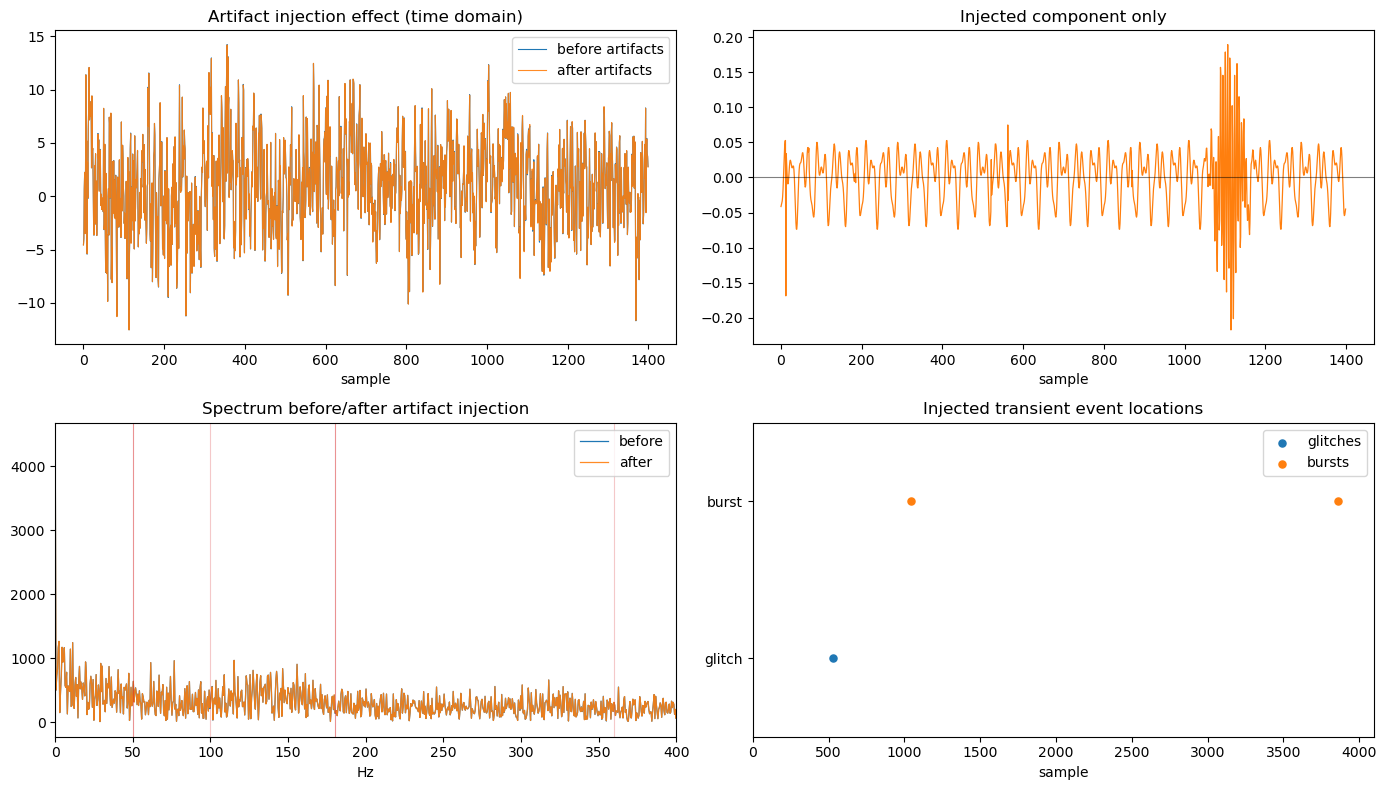

In [5]:
artifact_config = {
    'sampling_frequency': FS,
    'enable_lines': True,
    'lines': [
        {'freq': 50.0, 'amp': 0.03, 'phase': 'random', 'harmonics': [1, 2]},
        {'freq': 180.0, 'amp': [0.01, 0.02], 'phase': 'random', 'harmonics': [1]},
    ],
    'enable_glitches': True,
    'glitch_rate': 3.0,
    'glitch_amp_range': [0.12, 0.25],
    'glitch_templates': ['impulse', 'exp_decay', 'damped_sine', 'ringing'],
    'glitch_duration_samples': [32, 128],
    'enable_bursts': True,
    'burst_rate': 1.5,
    'burst_amp_range': [0.08, 0.18],
    'burst_duration_samples': [80, 220],
    'enable_sparse_impulses': True,
    'impulse_probability': 2e-3,
    'impulse_sigma': 0.15,
}
artifact = ArtifactInjector(artifact_config, seed=5)
artifact_trace, artifact_meta = artifact.apply(temporal_trace, return_metadata=True)
artifact_only = artifact_trace - temporal_trace

freqs = np.fft.rfftfreq(N, d=1.0 / FS)
base_spec = np.abs(np.fft.rfft(temporal_trace))
artifact_spec = np.abs(np.fft.rfft(artifact_trace))

line_freqs = [line['freq'] for line in artifact_config['lines']]

glitch_starts = [g['start'] for g in artifact_meta.get('glitches', {}).get('glitches', [])]
burst_starts = [b['start'] for b in artifact_meta.get('bursts', {}).get('bursts', [])]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(temporal_trace[:1400], lw=0.8, label='before artifacts')
axes[0, 0].plot(artifact_trace[:1400], lw=0.8, alpha=0.9, label='after artifacts')
axes[0, 0].set_title('Artifact injection effect (time domain)')
axes[0, 0].set_xlabel('sample')
axes[0, 0].legend(loc='upper right')

axes[0, 1].plot(artifact_only[:1400], lw=0.9, color='tab:orange')
axes[0, 1].axhline(0.0, color='black', lw=0.8, alpha=0.5)
axes[0, 1].set_title('Injected component only')
axes[0, 1].set_xlabel('sample')

axes[1, 0].plot(freqs, base_spec, lw=0.9, label='before')
axes[1, 0].plot(freqs, artifact_spec, lw=0.9, alpha=0.9, label='after')
for lf in line_freqs:
    axes[1, 0].axvline(lf, color='tab:red', lw=0.8, alpha=0.5)
    axes[1, 0].axvline(2 * lf, color='tab:red', lw=0.8, alpha=0.25)
axes[1, 0].set_xlim(0, 400)
axes[1, 0].set_title('Spectrum before/after artifact injection')
axes[1, 0].set_xlabel('Hz')
axes[1, 0].legend(loc='upper right')

if glitch_starts:
    axes[1, 1].scatter(glitch_starts, np.ones(len(glitch_starts)), label='glitches', s=26)
if burst_starts:
    axes[1, 1].scatter(burst_starts, 2 * np.ones(len(burst_starts)), label='bursts', s=26)
axes[1, 1].set_ylim(0.5, 2.5)
axes[1, 1].set_yticks([1, 2])
axes[1, 1].set_yticklabels(['glitch', 'burst'])
axes[1, 1].set_xlim(0, N)
axes[1, 1].set_title('Injected transient event locations')
axes[1, 1].set_xlabel('sample')
if glitch_starts or burst_starts:
    axes[1, 1].legend(loc='upper right')

plt.tight_layout()

artifact_meta


## 5. `MultiChannelNoiseGenerator`

This module generates arrays with shape `(C, N)`.

This demo shows:
- independent vs shared/private vs low-rank channel structure
- tuning `corr_strength` and measuring realized cross-channel correlation
- correlation matrix visualization for multiple settings


/tmp/ipykernel_3796906/3618431142.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[(0.0, 0.00153991920865265),
 (0.15, 0.16644142366020578),
 (0.35, 0.3174821546039927),
 (0.55, 0.5856708732305955),
 (0.8, 0.7964806993108949)]

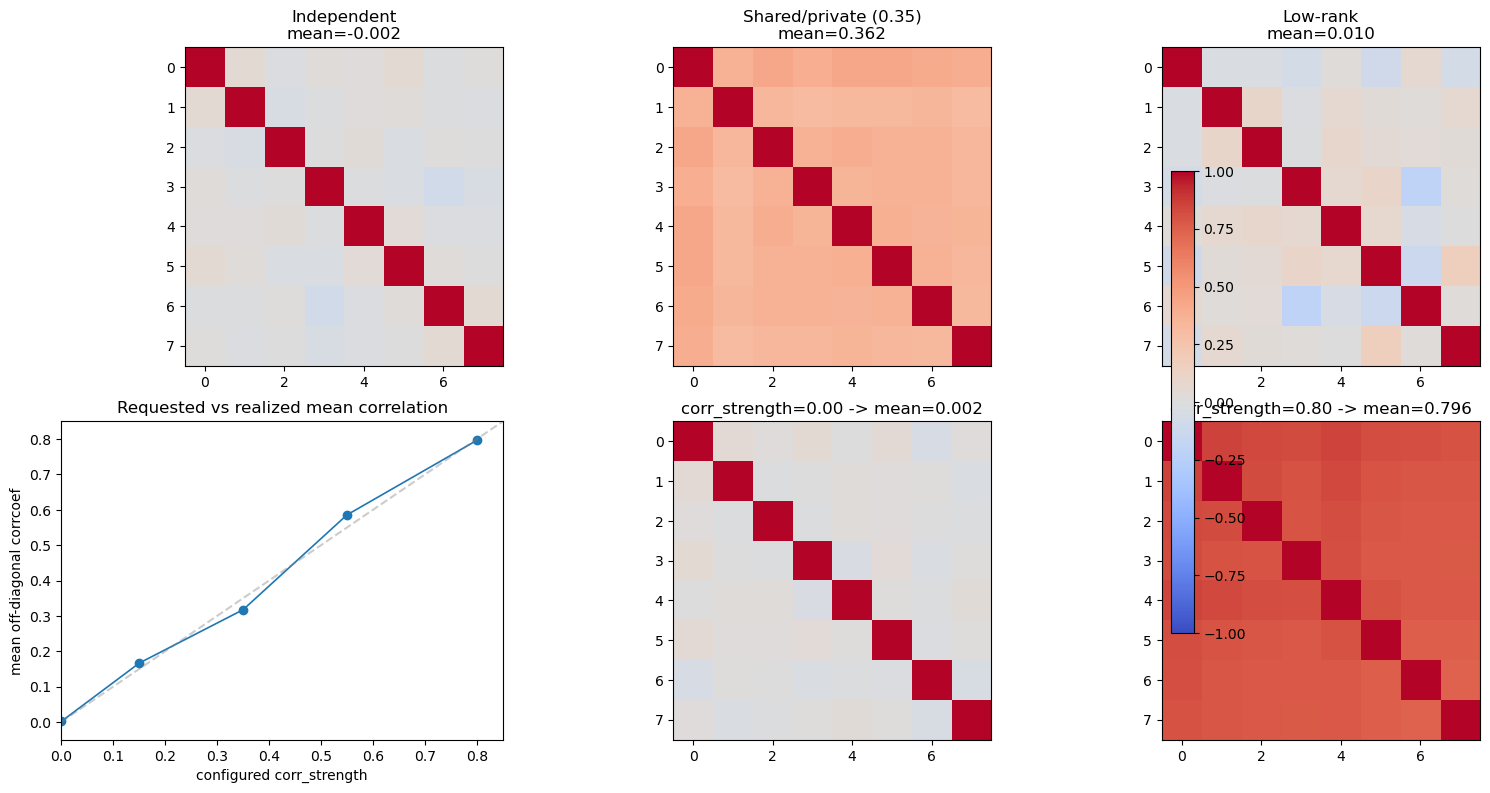

In [6]:
multichannel_config = {
    'mode': 'shared_private',
    'n_channels': 8,
    'corr_strength': 0.35,
    'channel_gain_jitter': 0.05,
    'n_latent': 3,
    'normalize_channel_variance': True,
}
mc = MultiChannelNoiseGenerator(custom_config, config=multichannel_config, seed=6)

independent, independent_meta = mc.generate_independent(8, N, return_metadata=True)
shared, shared_meta = mc.generate_shared_private(8, N, corr_strength=0.35, return_metadata=True)
lowrank, lowrank_meta = mc.generate_lowrank_correlated(8, N, n_latent=3, return_metadata=True)

corr_sweep = [0.0, 0.15, 0.35, 0.55, 0.8]
sweep_results = []
sweep_examples = {}
for c in corr_sweep:
    X, meta = mc.generate_shared_private(8, N, corr_strength=c, return_metadata=True)
    sweep_results.append((c, meta['mean_offdiag_corr']))
    if c in (0.0, 0.35, 0.8):
        sweep_examples[c] = X

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, data, title in [
    (axes[0, 0], independent, f"Independent\nmean={independent_meta['mean_offdiag_corr']:.3f}"),
    (axes[0, 1], shared, f"Shared/private (0.35)\nmean={shared_meta['mean_offdiag_corr']:.3f}"),
    (axes[0, 2], lowrank, f"Low-rank\nmean={lowrank_meta['mean_offdiag_corr']:.3f}"),
]:
    im = ax.imshow(np.corrcoef(data), vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_title(title)

axes[1, 0].plot([r[0] for r in sweep_results], [r[1] for r in sweep_results], marker='o', lw=1.2)
axes[1, 0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.4)
axes[1, 0].set_xlim(0, 0.85)
axes[1, 0].set_ylim(-0.05, 0.85)
axes[1, 0].set_title('Requested vs realized mean correlation')
axes[1, 0].set_xlabel('configured corr_strength')
axes[1, 0].set_ylabel('mean off-diagonal corrcoef')

for ax, c in zip([axes[1, 1], axes[1, 2]], [0.0, 0.8]):
    X = sweep_examples[c]
    ax.imshow(np.corrcoef(X), vmin=-1, vmax=1, cmap='coolwarm')
    realized = [r[1] for r in sweep_results if abs(r[0] - c) < 1e-12][0]
    ax.set_title(f'corr_strength={c:.2f} -> mean={realized:.3f}')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.tight_layout()

sweep_results


## 6. Composed Pipeline

The intended usage is compositional. Build the stationary base first, then layer temporal effects and artifacts. For multichannel data, generate the correlated array first, then apply multichannel temporal/artifact stages.

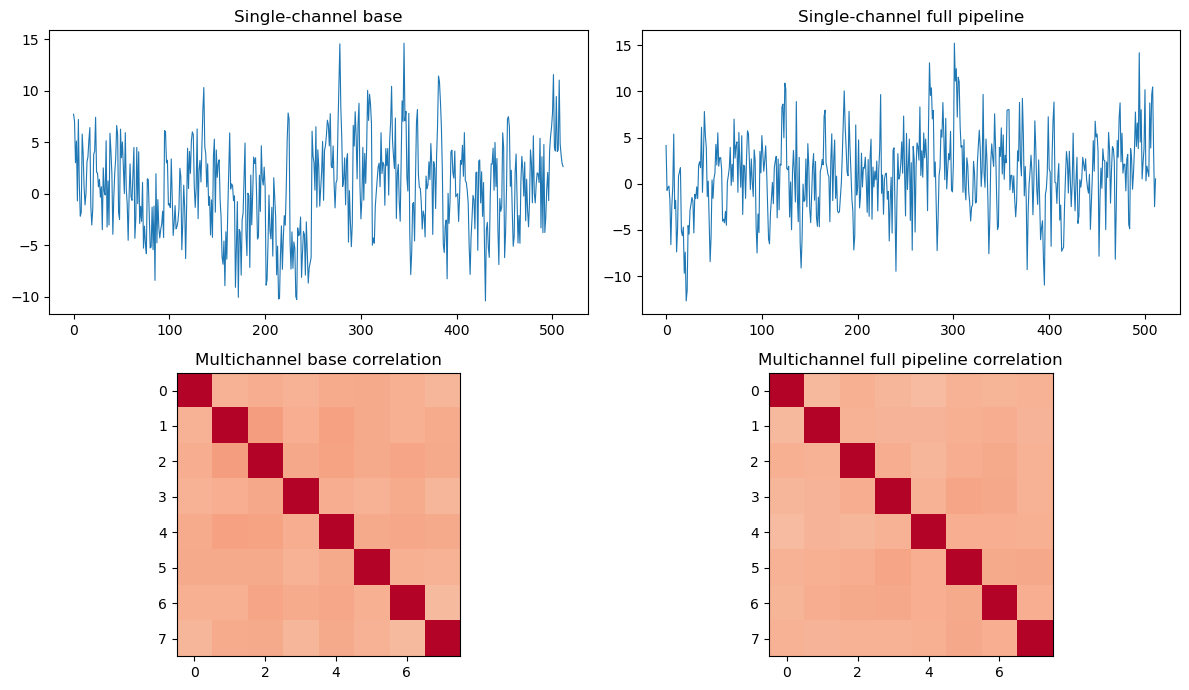

In [7]:
single_base = custom_gen.generate_noise(N)
single_temporal = temporal.apply(single_base, base_generator=custom_gen)
single_full = artifact.apply(single_temporal)

multi_base = mc.generate(N)
multi_temporal = temporal.apply_multichannel(multi_base, base_generator=mc)
multi_full = artifact.apply_multichannel(multi_temporal)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].plot(single_base[:512], lw=0.8)
axes[0, 0].set_title('Single-channel base')
axes[0, 1].plot(single_full[:512], lw=0.8)
axes[0, 1].set_title('Single-channel full pipeline')
axes[1, 0].imshow(np.corrcoef(multi_base), vmin=-1, vmax=1, cmap='coolwarm')
axes[1, 0].set_title('Multichannel base correlation')
axes[1, 1].imshow(np.corrcoef(multi_full), vmin=-1, vmax=1, cmap='coolwarm')
axes[1, 1].set_title('Multichannel full pipeline correlation')
plt.tight_layout()


## 7. Minimal Usage Recipes

Single-channel stationary noise:

```python
ng = NoiseGenerator(base_config, seed=123)
x = ng.generate_noise(N)
```

Single-channel pipeline:

```python
x = ng.generate_noise(N)
x = temporal.apply(x, base_generator=ng)
x = artifact.apply(x)
```

Multichannel pipeline:

```python
mc = MultiChannelNoiseGenerator(base_config, config=mc_config, seed=123)
X = mc.generate(N)
X = temporal.apply_multichannel(X, base_generator=mc)
X = artifact.apply_multichannel(X)
```

Custom PSD setup:

```python
np.save('my_psd.npy', np.vstack([freqs, psd_values]))
cfg = {'noise_type': 'my_psd.npy', 'noise_power': 1.0, 'sampling_frequency': fs}
ng = NoiseGenerator(cfg, seed=123)
```